In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
     f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest

In [2]:
applicants_df=pd.read_csv("credit_applicants.csv")
print("Default rate: {:.1%}".format(applicants_df["default"].mean()))

missing_credit_score=applicants_df[applicants_df["credit_bureau_score"].isna()]
print("Thin file applicants proportion: {:.1%}".format(len(missing_credit_score)/len(applicants_df)))

applicants_df["is_thin_file"]=applicants_df["credit_bureau_score"].isna().astype(int)
display(applicants_df[['applicant_id', 'credit_bureau_score', 'is_thin_file']].head())

##is_thin_file flag tells if the particular applicant has no credit bureau score (1), or if they do (0) 

Default rate: 20.2%
Thin file applicants proportion: 20.0%


,applicant_id,credit_bureau_score,is_thin_file
0,APP1000,NaN,1
1,APP1001,380.0,0
2,APP1002,788.0,0
3,APP1003,387.0,0
4,APP1004,493.0,0


 Stratifying default as the default rate is 20%, meaning a split done randomly can exclude defulted applicants from the test dataset.

In [3]:
features = [
    "age", "monthly_income_inr", "existing_loans_count", "credit_utilization_ratio",
    "upi_monthly_inflow_inr", "bounced_payments_count", "credit_bureau_score", "employment_type", "is_thin_file"
]

X = applicants_df[features].copy()
y = applicants_df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Training applicants:", len(X_train), " | Test applicants:", len(X_test))

Training applicants: 300  | Test applicants: 100


For the purpose of populating the NaN values (credit_bureau_score) in the dataset, median will be used. But in order to not let the Training data leak into the Test data, the sratified split is performed before the median calculation. Also the median is calculated using only the train data, and then used to populate the NaN values in both Test and Train data. This is done as per the StandardScaler fit-on-train-only rule.

For the purpose of encoding, one-hot encoder is used. Unlike label encoding, one-hot does not change individual categories into numbers, rather creates dummy columns for each of the categories with binary entries (0 or 1).

In [4]:
##Median Calculation
train_median_score = X_train["credit_bureau_score"].median()
X_train["credit_bureau_score"] = X_train["credit_bureau_score"].fillna(train_median_score)
X_test["credit_bureau_score"] = X_test["credit_bureau_score"].fillna(train_median_score)

##employment_type encoded using one-hot encoder
X_train_encoded = pd.get_dummies(X_train, columns=["employment_type"], drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=["employment_type"], drop_first=True, dtype=int)

numeric_cols = [
    "age", "monthly_income_inr", "existing_loans_count", 
    "credit_utilization_ratio", "upi_monthly_inflow_inr", 
    "bounced_payments_count", "credit_bureau_score"
]

scaler = StandardScaler()

scaler.fit(X_train_encoded[numeric_cols])

X_train_encoded[numeric_cols] = scaler.transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("Imputed missing bureau scores with training median:", train_median_score)
print("Processed Training Shape:", X_train_encoded.shape)
display(X_train_encoded.head())

Imputed missing bureau scores with training median: 612.0
Processed Training Shape: (300, 10)


,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,is_thin_file,employment_type_salaried,employment_type_self_employed
84,-1.145762,0.952812,0.053277,0.149735,0.995851,-0.227884,-0.148387,0,0,1
10,0.270945,-1.385434,-0.641639,-0.587877,-1.151228,-0.227884,0.048994,1,1,0
384,0.713666,-1.586508,-0.641639,-1.436132,0.076032,-1.127427,0.127947,0,0,1
359,-0.171776,0.287041,0.053277,1.588080,-0.656830,-0.227884,1.338550,0,0,0
11,1.333476,-0.576811,1.443108,0.186616,1.211575,-0.227884,0.476653,0,1,0


--- SIDE-BY-SIDE MODEL COMPARISON ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.76,0.3889,0.35,0.3684,0.7188
Decision Tree,0.65,0.2222,0.30,0.2553,0.5188


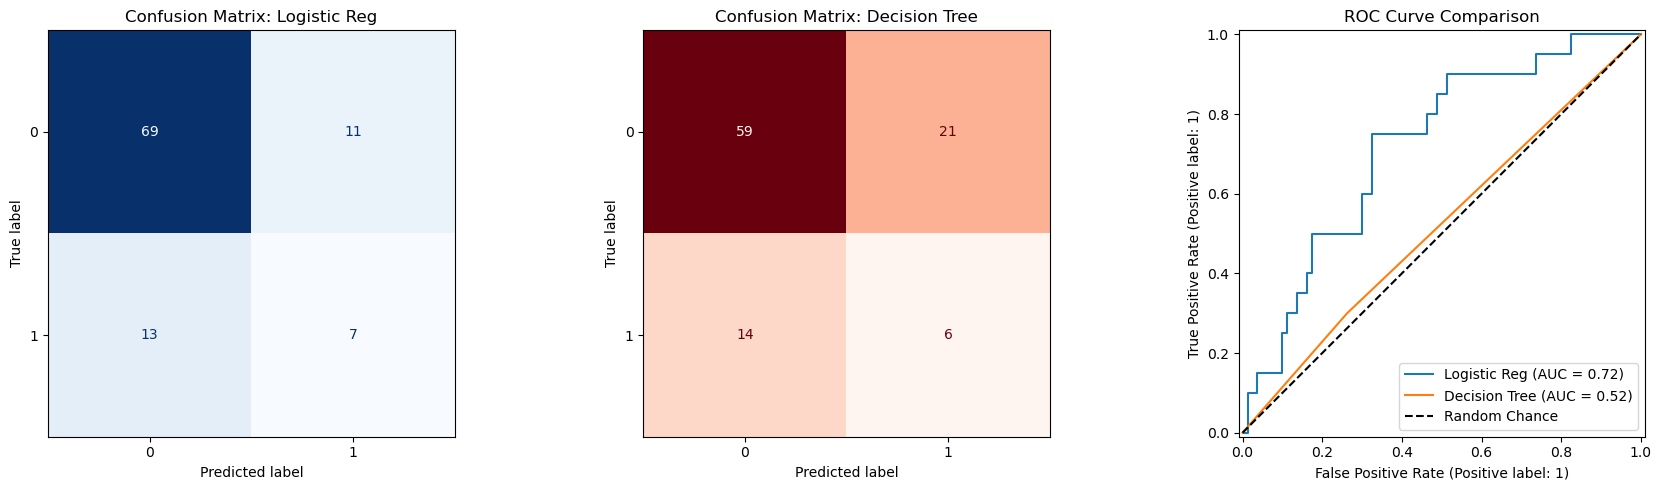

In [5]:
##Logistic Regression & Decision Tree classifier
##Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_encoded, y_train)

##Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_encoded, y_train)

##Metrics
models = {'Logistic Regression': log_reg, 'Decision Tree': dt_clf}
comparison_data = []

for name, model in models.items():
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    })

#Comparision table for Regression & Decision Tree
metrics_df = pd.DataFrame(comparison_data).set_index('Model')
print("--- SIDE-BY-SIDE MODEL COMPARISON ---")
display(metrics_df.round(4))

##Confusion Matrix and ROC curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(log_reg, X_test_encoded, y_test, 
                                      cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix: Logistic Reg')

ConfusionMatrixDisplay.from_estimator(dt_clf, X_test_encoded, y_test, 
                                      cmap='Reds', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix: Decision Tree')

RocCurveDisplay.from_estimator(log_reg, X_test_encoded, y_test, ax=axes[2], name='Logistic Reg')
RocCurveDisplay.from_estimator(dt_clf, X_test_encoded, y_test, ax=axes[2], name='Decision Tree')
axes[2].set_title('ROC Curve Comparison')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[2].legend()

plt.tight_layout()
plt.savefig('confusion_matrix_charts.png', dpi=300, bbox_inches='tight')
plt.show()

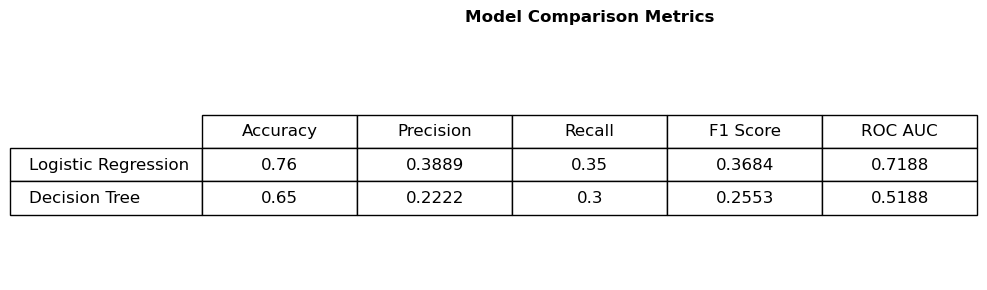

In [6]:
##Side-by-Side model comparision table as an image
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off') # Hide the standard chart axes
table = ax.table(cellText=metrics_df.round(4).values, 
                 colLabels=metrics_df.columns, 
                 rowLabels=metrics_df.index, 
                 loc='center', 
                 cellLoc='center')

table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title("Model Comparison Metrics", fontweight='bold', pad=20)

plt.savefig('model_side-by-side_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

--- RISK-BASED PRICING & MONOTONICITY TABLE ---


,Risk_Tier,Applicant_Count,Actual_Default_Rate,Assigned_Interest_Rate
0,Tier 1 (Low Risk),25,8.0%,8.0%
1,Tier 2 (Medium Risk),25,12.0%,12.5%
2,Tier 3 (High Risk),25,20.0%,18.0%
3,Tier 4 (Very High Risk),25,40.0%,22.5%


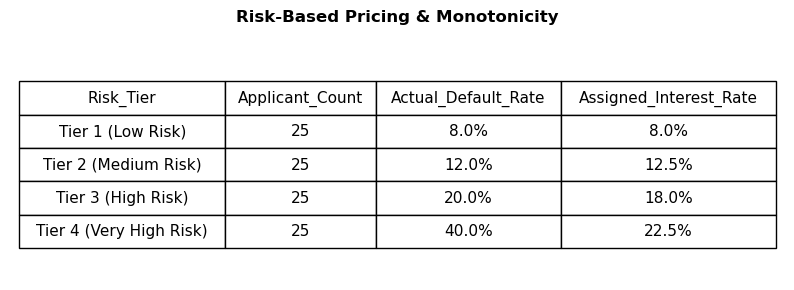

In [12]:
##Risk based pricing- assigning interest rates
pricing_df = pd.DataFrame({
    'Actual_Default': y_test,
    'Predicted_Prob': log_reg.predict_proba(X_test_encoded)[:, 1]
})

pricing_df['Risk_Tier'] = pd.qcut(
    pricing_df['Predicted_Prob'], 
    q=4, 
    labels=['Tier 1 (Low Risk)', 'Tier 2 (Medium Risk)', 'Tier 3 (High Risk)', 'Tier 4 (Very High Risk)']
)

##Assumed interest rate valuess for each bucket
interest_rate_map = {
    'Tier 1 (Low Risk)': '8.0%',
    'Tier 2 (Medium Risk)': '12.5%',
    'Tier 3 (High Risk)': '18.0%',
    'Tier 4 (Very High Risk)': '22.5%'
}
pricing_df['Assigned_Interest_Rate'] = pricing_df['Risk_Tier'].map(interest_rate_map)

##Predicted vs actual default rate
risk_table = pricing_df.groupby('Risk_Tier', observed=False).agg(
    Applicant_Count=('Actual_Default', 'count'),
    Actual_Default_Rate=('Actual_Default', 'mean'),
    Assigned_Interest_Rate=('Assigned_Interest_Rate', 'first')
).reset_index()

risk_table['Actual_Default_Rate'] = (risk_table['Actual_Default_Rate'] * 100).map('{:.1f}%'.format)

print("--- RISK-BASED PRICING & MONOTONICITY TABLE ---")
display(risk_table)

##Image output risk based pricing
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off') # Hide the standard chart axes

table = ax.table(cellText=risk_table.values, 
                 colLabels=risk_table.columns, 
                 loc='center', 
                 cellLoc='center')

table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(risk_table.columns))))
plt.title("Risk-Based Pricing & Monotonicity", fontweight='bold', pad=20)

plt.savefig('risk_based_pricing_table.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
#Anomaly Detection
behaviour_df=pd.read_csv("txn_behaviour.csv")
numeric_features=['txn_hour', 'is_new_device', 'txn_amount_inr']

##Standardize the numeric columns
scaler=StandardScaler()
scaled_features=scaler.fit_transform(behaviour_df[numeric_features])

##IsolationForest used to calculate rate of Anomalies
iso_forest=IsolationForest(random_state=42, contamination=15/265)
behaviour_df['is_anomaly']=iso_forest.fit_predict(scaled_features)

##Anomaly check against txn_id
injected_anomalies=behaviour_df[behaviour_df['txn_id'].str.startswith('BTXNA')]
caught_anomalies=injected_anomalies[injected_anomalies['is_anomaly']==-1]

print(f"Isolation Forest successfully flagged {len(caught_anomalies)} out of 15 injected anomalies.")
print("\n--- The Caught Anomalies ---")
display(caught_anomalies['txn_id'])
print("\n--- The Injected Anomalies ---")
display(injected_anomalies['txn_id'])

##Erroneously flagged transactions by the model
false_positives=behaviour_df[
    (behaviour_df['is_anomaly']==-1) &
    (~behaviour_df['txn_id'].str.startswith('BTXNA'))
]

print(f"Number of false positives: {len(false_positives)}")
print("\n--- Erroneously Flagged Transactions ---")
display(false_positives['txn_id'])

Isolation Forest successfully flagged 11 out of 15 injected anomalies.

--- The Caught Anomalies ---


250     BTXNA0
253     BTXNA3
254     BTXNA4
255     BTXNA5
256     BTXNA6
257     BTXNA7
258     BTXNA8
260    BTXNA10
261    BTXNA11
262    BTXNA12
263    BTXNA13
Name: txn_id, dtype: object


--- The Injected Anomalies ---


250     BTXNA0
251     BTXNA1
252     BTXNA2
253     BTXNA3
254     BTXNA4
255     BTXNA5
256     BTXNA6
257     BTXNA7
258     BTXNA8
259     BTXNA9
260    BTXNA10
261    BTXNA11
262    BTXNA12
263    BTXNA13
264    BTXNA14
Name: txn_id, dtype: object

Number of false positives: 4

--- Erroneously Flagged Transactions ---


3      BTXN5003
10     BTXN5010
81     BTXN5081
157    BTXN5157
Name: txn_id, dtype: object

OPTIONAL-
K-Means clustering on the standardized credit_applicants.csv to segregate applicants into behavioural groups

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

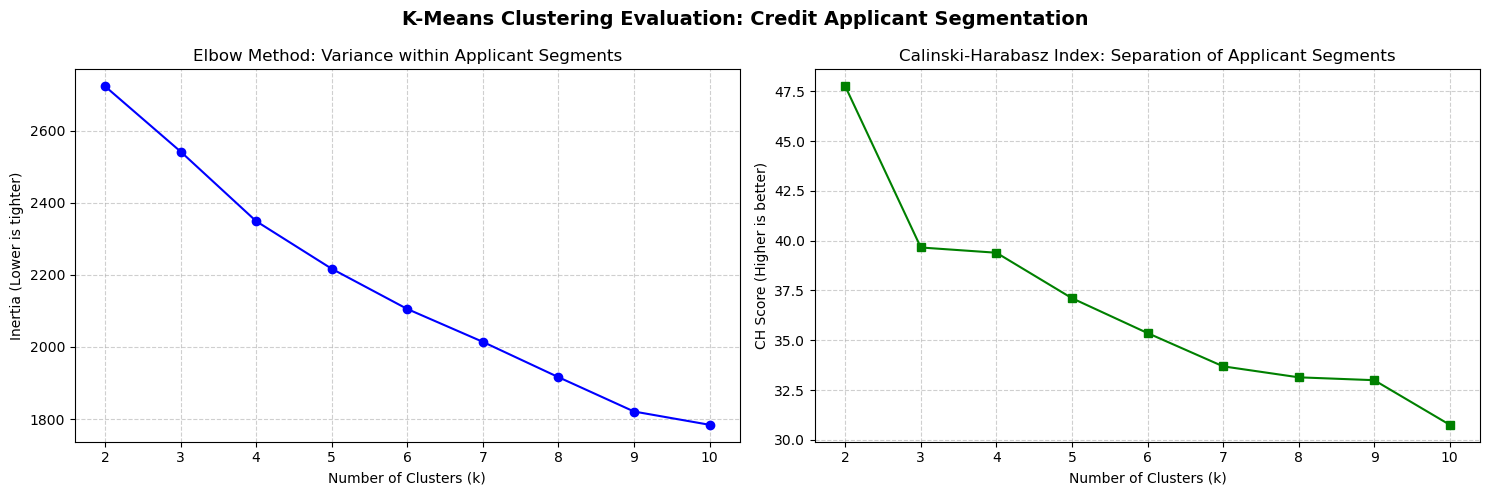

In [10]:
##Using train and test datasets from [4]
X_full=pd.concat([X_train_encoded, X_test_encoded])
y_full=pd.concat([y_train, y_test])

inertia_values=[]
ch_scores=[]
k_range=range(2, 11)

for k in k_range:
    kmeans=KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels=kmeans.fit_predict(X_full)

#The Elbow Method (how tightly packed the clusters are)
    inertia_values.append(kmeans.inertia_)  
#The Calinski-Harabasz Method (how well-separated the clusters are)
    ch_scores.append(calinski_harabasz_score(X_full, cluster_labels))

##Chart and image
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('K-Means Clustering Evaluation: Credit Applicant Segmentation', fontsize=14, fontweight='bold')

##Plot 1
axes[0].plot(k_range, inertia_values, marker='o', color='blue')
axes[0].set_title('Elbow Method: Variance within Applicant Segments')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Lower is tighter)')
axes[0].grid(True, linestyle='--', alpha=0.6)

##Plot 2
axes[1].plot(k_range, ch_scores, marker='s', color='green')
axes[1].set_title('Calinski-Harabasz Index: Separation of Applicant Segments')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('CH Score (Higher is better)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('kmeans_evaluation_charts.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
##Behavioural segmentation of applicants on the basis of K-means test
def evaluate_clusters(k_value):
    kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_full)
    
    df = pd.DataFrame({
        'Cluster': labels,
        'Actual_Default': y_full,
        'Is_Thin_File': X_full['is_thin_file']
    })
    
    summary = df.groupby('Cluster').agg(
        Applicant_Count=('Actual_Default', 'count'),
        Default_Rate=('Actual_Default', 'mean'),
        Thin_File_Rate=('Is_Thin_File', 'mean')
    ).reset_index()
    
    summary['Default_Rate'] = (summary['Default_Rate'] * 100).map('{:.1f}%'.format)
    summary['Thin_File_Rate'] = (summary['Thin_File_Rate'] * 100).map('{:.1f}%'.format)
    
    summary.insert(0, 'Model', f'k={k_value}')
    return summary

summary_k2 = evaluate_clusters(2)
summary_k5 = evaluate_clusters(5)

comparison_table = pd.concat([summary_k2, summary_k5], ignore_index=True)
comparison_table.set_index(['Model', 'Cluster'], inplace=True)
print("--- K-MEANS SEGMENTATION COMPARISON (k=2 vs k=5) ---")
display(comparison_table)

--- K-MEANS SEGMENTATION COMPARISON (k=2 vs k=5) ---


Applicant_Count Default_Rate Thin_File_Rate
Model Cluster                                             
k=2   0                    218        18.8%          20.6%
      1                    182        22.0%          19.2%
k=5   0                     80        15.0%          26.2%
      1                     89        14.6%          21.3%
      2                     80        27.5%          17.5%
      3                     72        30.6%          23.6%
      4                     79        15.2%          11.4%

An optional K-Means segmentation (k=5) was run to segment applicant behaviors. The model successfully identified high-risk sub-groups, with Cluster 3 significantly over-indexing on the default label (30.6% default rate compared to the 20% dataset baseline). Furthermore, the clustering revealed that thin-file status alone does not guarantee default, as Cluster 0 exhibited the highest thin-file concentration (26.2%) but maintained a low default rate (15.0%).